# Example: Stress-Testing the Minimum-Variance Portfolio

In this example, we take the minimum-variance allocation built in the previous notebook and stress-test it across 5,000 synthetic futures generated by the hybrid [JumpHMM](https://github.com/varnerlab/JumpHMM.jl) construction. We compare it head-to-head against an equal-weight 1/N benchmark, a buy-the-market benchmark, and a 1-year risk-free STRIPS baseline on tail-risk metrics — Value-at-Risk, Conditional VaR (Expected Shortfall), max drawdown, and fail rate — and zoom into the worst 5% of paths to see what failure looks like.

> __Frictionless Assumptions:__
>
> Throughout this notebook (and the rest of Session 1) we make the standard introductory simplifications: zero transaction costs, infinitely divisible shares, perfect order fills at each day's stated price, no taxes, no slippage, no margin or borrowing limits beyond the long-only constraint, and instant execution. These assumptions are pedagogical scaffolding — like the frictionless plane in introductory physics — that let us see the structural ideas (Markowitz optimization, hybrid forward simulation, distributional scorecards) without the operational noise of real-world trading. Sessions 2 through 4 introduce the frictions where they matter.

> __Learning Objectives:__
>
> * __Tail-risk evaluation under hybrid futures:__ Run a large Monte Carlo of synthetic futures via the hybrid SIM construction and compute tail-focused metrics (Value-at-Risk, Conditional VaR, P5 wealth, P95 drawdown). The standard error on the CVaR estimate tells you whether your sample size is large enough.
> * __Comparison against naive, market, and risk-free benchmarks:__ Score the calibrated minimum-variance allocation against an equal-weight 1/N benchmark, a buy-the-market benchmark, and a 1-year risk-free STRIPS baseline under the same set of synthetic futures. The same scenario is reused across all four portfolios so the comparison is apples-to-apples.
> * __Worst-case forensics and downstream baseline:__ Identify the worst 5% of paths, visualize their wealth trajectories alongside the median and the central corridor, and persist the scorecard plus raw arrays to disk so the adaptive rebalancing engine in Session 2 has a clear baseline to beat.

Let's get to work!
___

## Setup, Data, and Prerequisites
We begin by loading our packages and helper functions via the `Include.jl` file. This activates the local Julia environment and loads all dependencies.

This notebook depends on `code/src/data/minvar-allocation.jld2`, which is produced by the previous example. If you have not yet run the [BuildMinVariancePortfolio notebook](eCornell-AI-Finance-S1-Example-BuildMinVariancePortfolio-May-2026.ipynb), do that first — the load step in Task 1 will error otherwise.

In [1]:
# --- Load packages and helper functions ---
include("Include.jl"); # The Include.jl file activates the local Julia environment and imports all dependencies.

___
## Task 1: Load the Allocation and Run a 5,000-Path Stress Simulation
We load the calibrated minimum-variance allocation from the previous notebook, build the equal-weight benchmark, generate 5,000 forward paths from the hybrid SIM construction, and run buy-and-hold across four portfolios on the same set of futures: min-var, equal-weight, the market index, and a deterministic 1-year risk-free STRIPS baseline.

> __What are we going to do?__
>
> Load `minvar-allocation.jld2`, derive the 1/N equal-weight vector, set the 1-year risk-free rate `r_f = 0.045`, pull the surrogate models and current prices, generate one large hybrid scenario via [the `generate_hybrid_scenario(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.generate_hybrid_scenario), and run buy-and-hold four times: once for the min-var weights, once for equal weights, once for the market index using [the `backtest_buyhold_market(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_buyhold_market), and once for a synthetic risk-free portfolio whose terminal wealth is the deterministic compound `B₀·(1+r_f)^(n_steps/252)` on every path. The same `scenario` is reused for all four risky/risk-free portfolios so every comparison is on the same set of synthetic futures.

The code below loads the allocation file and the surrogate models, then declares the stress-test parameters.

In [2]:
B₀, r_f, allocation_weights, my_tickers, eq_weights, sim_estimates, σ_m = let

    # --- Step 1: Load the calibrated min-var allocation from the previous notebook ---
    minvar = load_results(joinpath(_PATH_TO_DATA, "minvar-allocation.jld2"));
    tickers = minvar["my_tickers"]::Vector{String};
    weights = Float64.(minvar["allocation_weights"]);
    estimates = minvar["sim_estimates"];
    σm = Float64(minvar["sigma_market"]);

    # --- Step 2: Build the 1/N equal-weight benchmark ---
    N = length(tickers);
    eqw = fill(1.0 / N, N);

    # --- Step 3: Risk-free baseline rate (1-year STRIPS) ---
    # 4.5% annualized — change this to whatever the prevailing 1-year zero-coupon
    # Treasury yield is on the day you run the notebook.
    rf = 0.045;

    # --- Step 4: Display loaded configuration ---
    println("Loaded minimum-variance allocation:")
    println("  $(N) tickers: $(tickers)")
    println("  σ_m (annualized growth rate): $(round(σm, digits=4))")
    println("  Min-var weights:    $(round.(weights .* 100, digits=2))%")
    println("  Equal-weight bench: $(round.(eqw .* 100, digits=2))%")
    println("  Risk-free baseline: $(round(rf*100, digits=2))% / year (1-year STRIPS)")

    10_000.0, rf, weights, tickers, eqw, estimates, σm
end;

Loaded minimum-variance allocation:
  10 tickers: ["AAPL", "MSFT", "NVDA", "JNJ", "JPM", "PG", "XOM", "BA", "GS", "AMD"]
  σ_m (annualized growth rate): 2.145
  Min-var weights:    [9.91, 14.1, 4.91, 32.62, 0.0, 38.46, -0.0, -0.0, -0.0, -0.0]%
  Equal-weight bench: [10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0, 10.0]%
  Risk-free baseline: 4.5% / year (1-year STRIPS)


With the allocation in hand we generate a single large hybrid forward scenario with **5,000 paths × 252 trading days × N tickers**, then run [the `backtest_buyhold(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_buyhold) for the min-var and equal-weight portfolios on `scenario.price_paths`, and [the `backtest_buyhold_market(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.backtest_buyhold_market) for the market index on `scenario.market_paths`. All three results have the same `MyBacktestResult` shape so the scorecard code can iterate over them uniformly.

In [3]:
scenario, result_mv, result_eq, result_mkt, result_rf, n_paths, n_steps = let

    # --- Step 1: Stress simulation parameters ---
    n_paths = 5_000;
    n_steps = 252;
    Δt      = 1.0 / 252.0;
    seed    = 2026;

    # --- Step 2: Load the surrogate models and the start-price snapshot ---
    market_model = MyMarketSurrogateModel();
    portfolio    = MyPortfolioSurrogateModel();
    calib        = MySIMCalibration();

    snap = MyCurrentPrices();
    snap_lookup = Dict(snap["tickers"] .=> snap["prices"]);
    start_prices = Dict(t => snap_lookup[t] for t ∈ my_tickers);

    # --- Step 3: Generate ONE 5,000-path hybrid scenario ---
    println("Generating $(n_paths)-path hybrid scenario ($(n_steps) days)...")
    scen = generate_hybrid_scenario(market_model, portfolio, calib, my_tickers;
        n_paths = n_paths,
        n_steps = n_steps,
        Δt      = Δt,
        start_prices = start_prices,
        label   = "Stress-Test ($(n_paths)p × $(n_steps)d)",
        seed    = seed);
    println("  scenario.price_paths shape:  $(size(scen.price_paths))")
    println("  scenario.market_paths shape: $(size(scen.market_paths))")

    # --- Step 4: Run buy-and-hold for the three risky portfolios ---
    r_mv  = backtest_buyhold(scen, my_tickers; B₀=B₀, offset=1, weights=allocation_weights);
    r_eq  = backtest_buyhold(scen, my_tickers; B₀=B₀, offset=1, weights=eq_weights);
    r_mkt = backtest_buyhold_market(scen; B₀=B₀, offset=1);

    # --- Step 5: Synthesize the risk-free baseline (1-year STRIPS, deterministic) ---
    # Every path ends at the same compound terminal wealth: B₀·(1+r_f)^(horizon).
    # Drawdown is identically zero, Sharpe convention 0 (zero vol), fail rate 0.
    rf_horizon_years = n_steps / 252;
    rf_terminal      = B₀ * (1 + r_f)^rf_horizon_years;
    r_rf = MyBacktestResult();
    r_rf.scenario_label = scen.label;
    r_rf.strategy_label = "Risk-Free STRIPS Buy-and-Hold";
    r_rf.final_wealth   = fill(rf_terminal, n_paths);
    r_rf.max_drawdowns  = zeros(n_paths);
    r_rf.sharpe_ratios  = zeros(n_paths);

    println("\nBuy-and-hold complete for all four portfolios:")
    println("  Min-var:      median terminal wealth = \$$(round(median(r_mv.final_wealth), digits=0))")
    println("  Equal-weight: median terminal wealth = \$$(round(median(r_eq.final_wealth), digits=0))")
    println("  Market:       median terminal wealth = \$$(round(median(r_mkt.final_wealth), digits=0))")
    println("  Risk-free:    deterministic terminal wealth = \$$(round(rf_terminal, digits=0))")

    scen, r_mv, r_eq, r_mkt, r_rf, n_paths, n_steps
end;

Generating 5000-path hybrid scenario (252 days)...
  scenario.price_paths shape:  (5000, 252, 10)
  scenario.market_paths shape: (5000, 252)

Buy-and-hold complete for all four portfolios:
  Min-var:      median terminal wealth = $13058.0
  Equal-weight: median terminal wealth = $14827.0
  Market:       median terminal wealth = $11162.0
  Risk-free:    deterministic terminal wealth = $10450.0


___
## Task 2: Tail-Risk Scorecard and Head-to-Head Comparison
We compute tail-focused metrics for all three portfolios — median, P5 (Value-at-Risk), [Conditional VaR / Expected Shortfall](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session3/#eCornellAIFinance.compute_cvar) at the 5% level, max drawdown percentiles, Sharpe, and fail rate — display them in a side-by-side scorecard, and overlay the terminal-wealth and max-drawdown distributions for visual comparison.

> __Tail-Risk Definitions:__
>
> * __Value-at-Risk (VaR) at level $\alpha$:__ the wealth threshold such that only $\alpha$ fraction of paths end below it. We use $\alpha = 5\%$, so $\text{VaR}_{5}$ is the 5th-percentile terminal wealth.
> * __Conditional VaR / Expected Shortfall (CVaR) at level $\alpha$:__ the **mean** terminal wealth across the worst $\alpha$ fraction of paths. CVaR sees the entire tail, not just the cutoff, so it is a strictly more informative tail measure than VaR.
> * __CVaR standard error:__ for $n$ paths and tail fraction $\alpha$, the tail has $n_{\text{tail}} = \lfloor \alpha n \rfloor$ samples and the SE of the CVaR estimate is approximately $\text{std}(\text{tail}) / \sqrt{n_{\text{tail}}}$. With 5,000 paths and $\alpha = 5\%$ that is $n_{\text{tail}} = 250$ — large enough for a stable point estimate but worth reporting alongside it.
> * __Fail rate:__ the fraction of paths that ended below the initial wealth $B_0$. A direct measure of "loss probability over the horizon".

> __What are we going to do?__
>
> For each of the three `MyBacktestResult` objects, compute the eight tail-risk metrics, assemble them into a comparison `DataFrame`, and display via the canonical `pretty_table` call. Then plot two overlay histograms: terminal wealth (with the P5 line marked for each portfolio) and max drawdown.

The code below builds the scorecard and stores it in `scorecard::DataFrame`.

In [4]:
scorecard = let

    # --- Helper: row of metrics for one MyBacktestResult ---
    function tail_metrics(name::String, r::MyBacktestResult, B0::Float64)
        wealth = r.final_wealth;
        n      = length(wealth);
        n_tail = max(1, floor(Int, 0.05 * n));
        sorted_wealth = sort(wealth);
        tail = sorted_wealth[1:n_tail];
        cvar5 = mean(tail);
        # SE is undefined when the tail is constant (e.g. risk-free); coerce to 0.
        cvar5_se = (length(tail) > 1) ? std(tail) / sqrt(n_tail) : 0.0;
        return (
            Portfolio   = name,
            Median      = round(median(wealth), digits=0),
            P10         = round(quantile(wealth, 0.10), digits=0),
            VaR_5       = round(quantile(wealth, 0.05), digits=0),
            CVaR_5      = round(cvar5, digits=0),
            CVaR_5_SE   = round(cvar5_se, digits=0),
            Med_DD_pct  = round(median(r.max_drawdowns) * 100, digits=2),
            P95_DD_pct  = round(quantile(r.max_drawdowns, 0.95) * 100, digits=2),
            Med_Sharpe  = round(median(r.sharpe_ratios), digits=3),
            Fail_pct    = round(mean(wealth .< B0) * 100, digits=1),
        );
    end

    # --- Build the scorecard rows ---
    rows = [
        tail_metrics("Min-Var",         result_mv,  B₀),
        tail_metrics("Equal-Weight",    result_eq,  B₀),
        tail_metrics("Market (SPY)",    result_mkt, B₀),
        tail_metrics("Risk-Free $(round(r_f*100, digits=1))%", result_rf, B₀),
    ];
    df = DataFrame(rows);

    # --- Display via canonical pretty_table kwargs ---
    println("Tail-risk scorecard over $(n_paths) paths, $(n_steps)-day horizon:")
    pretty_table(df; backend = :text,
        fit_table_in_display_horizontally = false,
        fit_table_in_display_vertically = false,
        table_format = TextTableFormat(borders = text_table_borders__compact))

    # --- Print convergence note (skip risk-free which is deterministic) ---
    n_tail = floor(Int, 0.05 * n_paths);
    println()
    println("CVaR sample size: $(n_tail) paths in the 5% tail.")
    println("CVaR standard errors above are analytical (std(tail) / √n_tail).")
    println("Standard-error / point-estimate ratios:")
    for row ∈ eachrow(df)
        if row.CVaR_5 > 0 && row.CVaR_5_SE > 0
            ratio = row.CVaR_5_SE / abs(row.CVaR_5);
            println("  $(rpad(row.Portfolio, 20)) SE / |CVaR| = $(round(ratio*100, digits=2))%")
        else
            println("  $(rpad(row.Portfolio, 20)) deterministic — SE = 0 by construction")
        end
    end
    println("Rule of thumb: if any non-deterministic SE/|CVaR| ratio exceeds ~1%, increase n_paths.")

    df
end;

Tail-risk scorecard over 5000 paths, 252-day horizon:
 ---------------- --------- --------- --------- --------- ----------- ------------ ------------ ------------ ----------
       Portfolio    Median       P10     VaR_5    CVaR_5   CVaR_5_SE   Med_DD_pct   P95_DD_pct   Med_Sharpe   Fail_pct 
          String   Float64   Float64   Float64   Float64     Float64      Float64      Float64      Float64    Float64 
 ---------------- --------- --------- --------- --------- ----------- ------------ ------------ ------------ ----------
         Min-Var   13058.0   10549.0    9857.0    9126.0        37.0        12.62        23.07        1.562        5.8
    Equal-Weight   14827.0   10791.0    9773.0    8816.0        51.0        17.95        32.41        1.681        5.8
    Market (SPY)   11162.0    8882.0    8260.0    7596.0        36.0        13.67        28.48        0.667       26.5
  Risk-Free 4.5%   10450.0   10450.0   10450.0   10450.0         0.0          0.0          0.0          0.0  

The histograms below overlay the terminal wealth and max-drawdown distributions for the three risky portfolios, with the deterministic risk-free baseline shown as a vertical green line on each panel. The terminal-wealth axis is **scaled by initial wealth** (`final_wealth / B₀`), so `1.0` is break-even and the risk-free vertical line sits at `1 + r_f = 1.045`. Look for separation in the left tail of the wealth panel (the worst paths) and the right tail of the drawdown panel (the deepest losses) — that is where the tail risk lives.

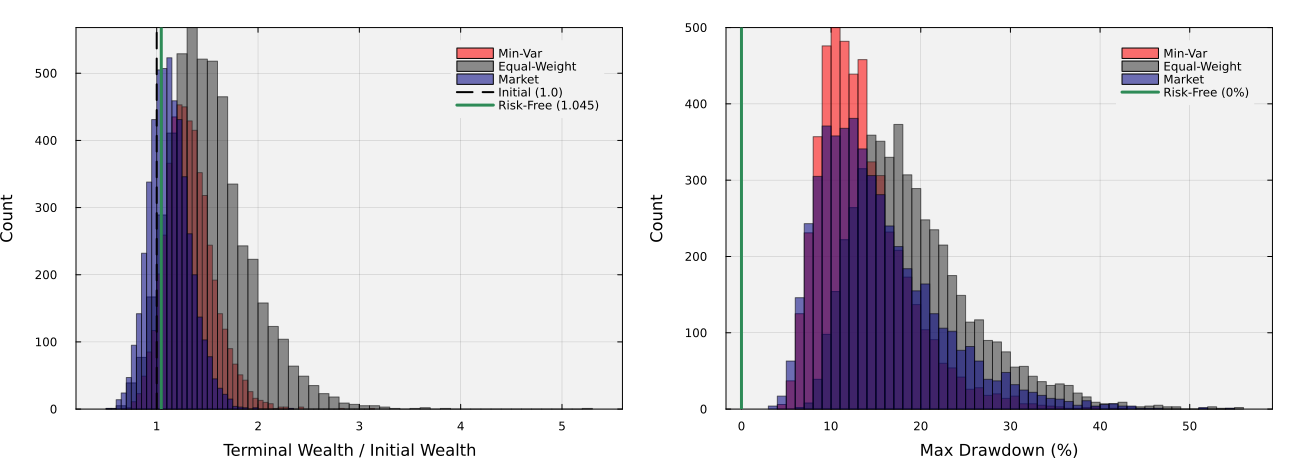

In [5]:
let
    rf_multiple = result_rf.final_wealth[1] / B₀;  # 1 + r_f for 1-year horizon

    # --- Panel 1: terminal wealth overlay (scaled by B₀) ---
    p1 = histogram(result_mv.final_wealth ./ B₀, bins=60, alpha=0.55, color=:red,
        label="Min-Var", xlabel="Terminal Wealth / Initial Wealth", ylabel="Count",
        fontsize=18);
    histogram!(p1, result_eq.final_wealth ./ B₀, bins=60, alpha=0.55, color=:gray20, label="Equal-Weight");
    histogram!(p1, result_mkt.final_wealth ./ B₀, bins=60, alpha=0.55, color=:navy, label="Market");
    vline!(p1, [1.0], lw=2, ls=:dash, c=:black, label="Initial (1.0)");
    vline!(p1, [rf_multiple], lw=3, c=:seagreen, label="Risk-Free ($(round(rf_multiple, digits=3)))");
    plot!(p1, bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright);

    # --- Panel 2: max drawdown overlay ---
    p2 = histogram(result_mv.max_drawdowns .* 100, bins=60, alpha=0.55, color=:red,
        label="Min-Var", xlabel="Max Drawdown (%)", ylabel="Count",
        fontsize=18);
    histogram!(p2, result_eq.max_drawdowns .* 100, bins=60, alpha=0.55, color=:gray20, label="Equal-Weight");
    histogram!(p2, result_mkt.max_drawdowns .* 100, bins=60, alpha=0.55, color=:navy, label="Market");
    vline!(p2, [0.0], lw=3, c=:seagreen, label="Risk-Free (0%)");
    plot!(p2, bg="gray95", background_color_outside="white",
        framestyle=:box, fg_legend=:transparent, legend=:topright);

    plot(p1, p2, layout=(1, 2), size=(1300, 460), margin=5Plots.mm)
end

___
## Task 3: Worst-Case Forensics and Hand-Off Baseline
We zoom into the worst 5% of paths for the minimum-variance portfolio (the same 250 paths underlying its CVaR), plot their wealth trajectories alongside the median and the central P5–P95 corridor, print a one-paragraph stress narrative, and save the full scorecard plus raw arrays to disk as the baseline that the adaptive rebalancing engine in Session 2 must beat.

> __What are we going to do?__
>
> Identify the indices of the worst 5% of paths sorted by min-var terminal wealth, recompute their wealth trajectories from `scenario.price_paths`, plot them in red against the all-paths median (thick black) and a P5–P95 gray band, then save `stress-test-baseline.jld2` with the scorecard, the raw final-wealth / drawdown / Sharpe arrays for all three portfolios, and the seed / `n_paths` / `n_steps` for reproducibility.

The code below identifies the worst-case paths and renders the trajectory plot.

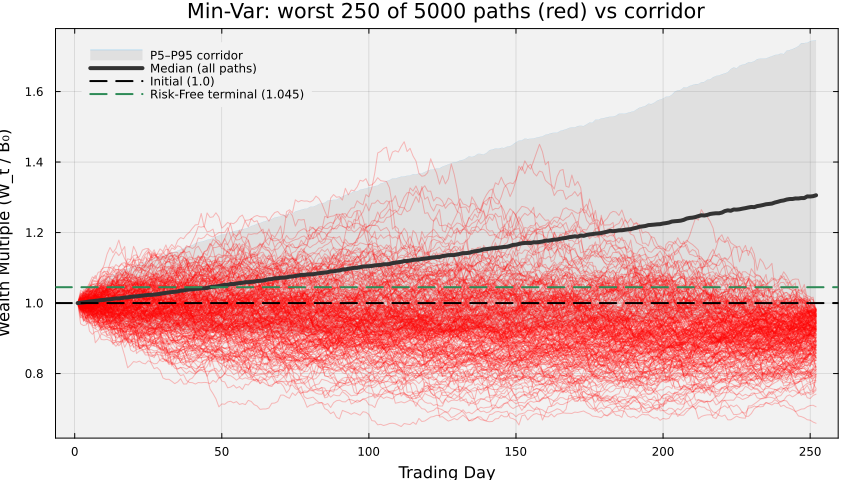

In [6]:
let
    # --- Step 1: Identify the worst 5% of paths for the min-var portfolio ---
    n_tail = max(1, floor(Int, 0.05 * n_paths));
    worst_idx = partialsortperm(result_mv.final_wealth, 1:n_tail);
    IW = B₀;  # initial wealth — scale wealth trajectories so 1.0 = break-even
    rf_multiple = result_rf.final_wealth[1] / B₀;  # 1 + r_f over the horizon

    # --- Step 2: Recompute wealth trajectories for ALL paths (min-var) ---
    K = length(my_tickers);
    wealth_all = zeros(n_steps, n_paths);
    for p ∈ 1:n_paths
        shares = [(B₀ * allocation_weights[k]) / scenario.price_paths[p, 1, k] for k ∈ 1:K];
        for t ∈ 1:n_steps
            wealth_all[t, p] = sum(shares[k] * scenario.price_paths[p, t, k] for k ∈ 1:K);
        end
    end

    # --- Step 3: Median + P5–P95 corridor + worst-tail paths ---
    median_traj = [median(wealth_all[t, :]) for t ∈ 1:n_steps];
    p05_traj    = [quantile(wealth_all[t, :], 0.05) for t ∈ 1:n_steps];
    p95_traj    = [quantile(wealth_all[t, :], 0.95) for t ∈ 1:n_steps];

    # --- Step 4: Plot the corridor + worst-tail in red, scaled by IW ---
    p = plot(1:n_steps, p95_traj ./ IW,
        fillrange = p05_traj ./ IW, fillalpha = 0.20, fillcolor = :gray60,
        lw = 0, label = "P5–P95 corridor",
        xlabel = "Trading Day",
        ylabel = "Wealth Multiple (W_t / B₀)",
        fontsize = 18,
        size = (850, 480));
    # the worst 5% of paths in red, lightly drawn
    for idx ∈ worst_idx
        plot!(p, 1:n_steps, wealth_all[:, idx] ./ IW,
            lw = 1, c = :red, alpha = 0.25, label = "");
    end
    plot!(p, 1:n_steps, median_traj ./ IW, lw = 4, c = :gray20, label = "Median (all paths)");
    hline!(p, [1.0], lw = 2, ls = :dash, c = :black, label = "Initial (1.0)");
    hline!(p, [rf_multiple], lw = 2, ls = :dash, c = :seagreen,
        label = "Risk-Free terminal ($(round(rf_multiple, digits=3)))");
    plot!(p, bg = "gray95",
        background_color_outside = "white",
        framestyle = :box,
        fg_legend = :transparent,
        legend = :topleft);
    title!(p, "Min-Var: worst $(n_tail) of $(n_paths) paths (red) vs corridor")
    display(p)
end

The narrative below summarizes how each portfolio behaves in the worst 5% of paths and quantifies how much downside protection (or harm) the minimum-variance optimization adds versus the naive benchmarks.

In [7]:
let
    n_tail = max(1, floor(Int, 0.05 * n_paths));

    function tail_loss_pct(r::MyBacktestResult, B0::Float64, ntail::Int)
        worst = sort(r.final_wealth)[1:ntail];
        median_loss = (B0 - median(worst)) / B0 * 100;
        worst_loss  = (B0 - minimum(worst)) / B0 * 100;
        return (median_loss = median_loss, worst_loss = worst_loss);
    end

    mv  = tail_loss_pct(result_mv,  B₀, n_tail);
    eq  = tail_loss_pct(result_eq,  B₀, n_tail);
    mkt = tail_loss_pct(result_mkt, B₀, n_tail);
    # Risk-free is deterministic — every path ends at the same +r_f total return.
    rf_total_return = (result_rf.final_wealth[1] - B₀) / B₀ * 100;

    println("="^80)
    println("STRESS NARRATIVE — worst 5% of $(n_paths) paths ($(n_tail) tail paths):")
    println("="^80)
    println()
    println("In the worst 5% of synthetic futures, the median loss vs initial wealth is:")
    println("  Min-Var:      $(round(mv.median_loss,  digits=1))%   (worst single path: $(round(mv.worst_loss,  digits=1))%)")
    println("  Equal-Weight: $(round(eq.median_loss,  digits=1))%   (worst single path: $(round(eq.worst_loss,  digits=1))%)")
    println("  Market:       $(round(mkt.median_loss, digits=1))%   (worst single path: $(round(mkt.worst_loss, digits=1))%)")
    println("  Risk-Free:    +$(round(rf_total_return, digits=1))% gain on every path (deterministic)")
    println()
    advantage_eq  = eq.median_loss  - mv.median_loss;
    advantage_mkt = mkt.median_loss - mv.median_loss;
    println("Min-Var advantage in the worst 5% (positive = min-var loses LESS than benchmark):")
    println("  vs Equal-Weight: $(round(advantage_eq,  digits=1)) percentage points")
    println("  vs Market (SPY): $(round(advantage_mkt, digits=1)) percentage points")
    println()
    # The risky-vs-risk-free trade-off
    mv_median_total = (median(result_mv.final_wealth) - B₀) / B₀ * 100;
    println("Risk vs return trade-off (median terminal return vs risk-free):")
    println("  Min-Var median total return: $(round(mv_median_total, digits=1))% over the horizon")
    println("  Risk-Free total return:      $(round(rf_total_return, digits=1))% over the horizon")
    println("  Excess return vs risk-free:  $(round(mv_median_total - rf_total_return, digits=1)) percentage points")
    println("  → This is the 'premium' min-var earns for accepting the tail risk shown above.")
    println("="^80)
end

STRESS NARRATIVE — worst 5% of 5000 paths (250 tail paths):

In the worst 5% of synthetic futures, the median loss vs initial wealth is:
  Min-Var:      7.3%   (worst single path: 34.1%)
  Equal-Weight: 9.7%   (worst single path: 49.3%)
  Market:       22.3%   (worst single path: 48.6%)
  Risk-Free:    +4.5% gain on every path (deterministic)

Min-Var advantage in the worst 5% (positive = min-var loses LESS than benchmark):
  vs Equal-Weight: 2.4 percentage points
  vs Market (SPY): 14.9 percentage points

Risk vs return trade-off (median terminal return vs risk-free):
  Min-Var median total return: 30.6% over the horizon
  Risk-Free total return:      4.5% over the horizon
  Excess return vs risk-free:  26.1 percentage points
  → This is the 'premium' min-var earns for accepting the tail risk shown above.


Finally we save the stress-test baseline to disk for downstream sessions. The next notebook (Session 2's adaptive rebalancing engine) will load this file and try to beat the buy-and-hold tail metrics under the same set of futures.

The code below saves the handoff file using [the `save_results(...)` function](https://varnerlab.org/eCornell-AI-finance-lectures/dev/session1/#eCornellAIFinance.save_results).

In [8]:
let
    save_path = joinpath(_PATH_TO_DATA, "stress-test-baseline.jld2");
    save_results(save_path, Dict(
        "my_tickers"         => my_tickers,
        "allocation_weights" => allocation_weights,
        "eq_weights"         => eq_weights,
        # raw per-path arrays for all four portfolios
        "mv_final_wealth"    => result_mv.final_wealth,
        "mv_max_drawdowns"   => result_mv.max_drawdowns,
        "mv_sharpe_ratios"   => result_mv.sharpe_ratios,
        "eq_final_wealth"    => result_eq.final_wealth,
        "eq_max_drawdowns"   => result_eq.max_drawdowns,
        "eq_sharpe_ratios"   => result_eq.sharpe_ratios,
        "mkt_final_wealth"   => result_mkt.final_wealth,
        "mkt_max_drawdowns"  => result_mkt.max_drawdowns,
        "mkt_sharpe_ratios"  => result_mkt.sharpe_ratios,
        "rf_final_wealth"    => result_rf.final_wealth,
        "rf_max_drawdowns"   => result_rf.max_drawdowns,
        "rf_sharpe_ratios"   => result_rf.sharpe_ratios,
        # scorecard summary as a Dict (JLD2 round-trips this cleanly)
        "scorecard"          => Dict(string(c) => scorecard[!, c] for c ∈ names(scorecard)),
        # reproducibility metadata
        "B₀"                 => B₀,
        "r_f"                => r_f,
        "n_paths"            => n_paths,
        "n_steps"            => n_steps,
        "seed"               => 2026,
    ));

    println("Saved stress-test baseline to: $(save_path)")
    println("  Four portfolios × $(n_paths) paths × $(n_steps) days")
    println("  Scorecard rows: $(nrow(scorecard))")
    println("  Hand-off ready for Session 2 adaptive rebalancing engine.")
end;

Saved stress-test baseline to: /Users/jdv27/Desktop/julia_work/eCornell-AI-finance-lectures/lectures/session-1/data/stress-test-baseline.jld2
  Four portfolios × 5000 paths × 252 days
  Scorecard rows: 4
  Hand-off ready for Session 2 adaptive rebalancing engine.


___
## Summary
This example stress-tested the calibrated minimum-variance allocation across 5,000 hybrid synthetic futures, compared it head-to-head against an equal-weight benchmark and a buy-the-market benchmark on tail-risk metrics, zoomed into the worst 5% of paths to see what failure looks like, and saved the resulting scorecard and raw arrays as the baseline that the adaptive rebalancing engine in Session 2 must beat.

> __Key Takeaways:__
>
> * __Tail risk is a distribution, not a number:__ Median terminal wealth is the easy summary, but Conditional VaR (Expected Shortfall) at the 5% level captures the *average* loss in the bad tail and is the more informative measure of downside risk. The standard error on the CVaR estimate tells you whether your sample size is large enough to trust the number.
> * __Optimization needs a benchmark to be meaningful:__ Min-variance only earns its keep if it actually beats naive alternatives like equal-weight 1/N or just buying the market. The head-to-head scorecard makes the comparison concrete on every metric — terminal wealth, drawdown, Sharpe, fail rate, and CVaR.
> * __The baseline scorecard is the bar Session 2 must clear:__ The min-var buy-and-hold outcome — both summary statistics and raw per-path arrays — is persisted to disk so the adaptive rebalancing engine can be evaluated against the same set of futures. Session 2 wins only if rebalancing tightens the tail or lifts the median without inflating the drawdown.

### Disclaimer
This content is for educational purposes only and does not constitute investment advice. The examples use synthetic data and simplified models.

___